In [1]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_probability as tfp
import warnings
warnings.filterwarnings('ignore')
import math
print(gym.__version__)
import time 

2023-10-22 07:52:47.875015: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-22 07:52:47.995633: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-22 07:52:48.034069: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-22 07:52:49.660867: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

0.26.2


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

!nvidia-smi


Sun Oct 22 07:52:52 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.61.05    Driver Version: 520.61.05    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  On   | 00000000:1A:00.0 Off |                  N/A |
| 22%   23C    P8    20W / 250W |      1MiB / 11264MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  On   | 00000000:1B:00.0 Off |                  N/A |
| 22%   

In [3]:
class Policy(tf.keras.Model):
    def __init__(self):
        super(Policy, self).__init__()
        self.l1 = keras.layers.Dense(32, activation='linear', input_shape=(4,))
        self.l2 = keras.layers.Dense(12, activation='relu', input_shape=(32,))
        self.l3  = keras.layers.Dense(2, activation='softmax')


        #self.saved_log_probs = []
        #self.rewards = []

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        
        return x


model_policy  = Policy()

'''
model = keras.Sequential([
    keras.layers.Dense(32, activation='linear', input_shape=(4,)),
    keras.layers.Dense(12, activation='relu', input_shape=(32,)),
    keras.layers.Dense(2, activation='softmax')])  # Two actions: left and right])
'''

2023-10-22 07:52:53.290270: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-22 07:52:54.111201: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 304 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:1b:00.0, compute capability: 7.5


"\nmodel = keras.Sequential([\n    keras.layers.Dense(32, activation='linear', input_shape=(4,)),\n    keras.layers.Dense(12, activation='relu', input_shape=(32,)),\n    keras.layers.Dense(2, activation='softmax')])  # Two actions: left and right])\n"

In [4]:
class Value(tf.keras.Model):
    def __init__(self):
        super(Value, self).__init__()
        self.l1 = keras.layers.Dense(32, activation='linear', input_shape=(4,))
        self.l2 = keras.layers.Dense(12, activation='relu', input_shape=(32,))
        self.l3  = keras.layers.Dense(1, activation='linear')


        #self.saved_log_probs = []
        #self.rewards = []

    def forward(self, x):
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        
        return x
    
model_value  = Value()


In [5]:
#!pip install gym==0.26.2


CartPole-v0, episode 0, score 20.0
CartPole-v0, episode 1, score 12.0
CartPole-v0, episode 2, score 17.0
CartPole-v0, episode 3, score 35.0
CartPole-v0, episode 4, score 17.0
CartPole-v0, episode 5, score 26.0
CartPole-v0, episode 6, score 12.0
CartPole-v0, episode 7, score 14.0
CartPole-v0, episode 8, score 31.0
CartPole-v0, episode 9, score 19.0
CartPole-v0, episode 10, score 21.0
CartPole-v0, episode 11, score 35.0
CartPole-v0, episode 12, score 23.0
CartPole-v0, episode 13, score 17.0
CartPole-v0, episode 14, score 27.0
CartPole-v0, episode 15, score 13.0
CartPole-v0, episode 16, score 114.0
CartPole-v0, episode 17, score 22.0
CartPole-v0, episode 18, score 13.0
CartPole-v0, episode 19, score 35.0
CartPole-v0, episode 20, score 29.0
CartPole-v0, episode 21, score 48.0
CartPole-v0, episode 22, score 19.0
CartPole-v0, episode 23, score 45.0
CartPole-v0, episode 24, score 13.0
CartPole-v0, episode 25, score 17.0
CartPole-v0, episode 26, score 27.0
CartPole-v0, episode 27, score 16.0
C

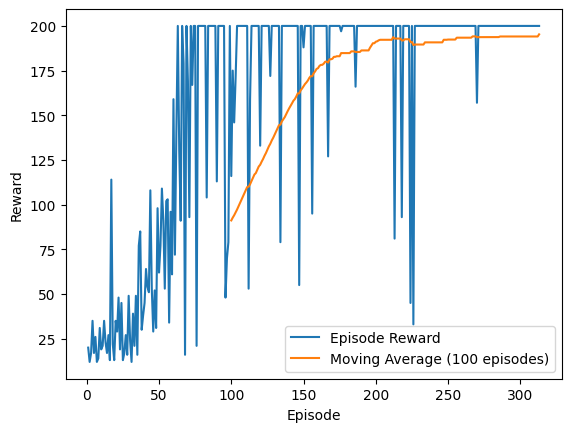

Time Lapsed = 0:10:4.441333770751953


In [7]:
start_time = time.time()

env = gym.make("CartPole-v0")

#  neural network for the policy

# optimizer for training
optimizer_policy = keras.optimizers.Adam(learning_rate=0.005)
optimizer_value = keras.optimizers.Adam(learning_rate=0.005)

#  discount factor
gamma = 0.95
#  gradient clipping
max_grad_norm = 1

#num_episodes = 5000

last_100_episodes =[]
all_episodes = []
episode_rewards = []
#for batch in range (0, 800):
avg_reward = 0
batch=0
while avg_reward < env.spec.reward_threshold and batch <10000: 
    
    num_episodes = 1
# Training loop
    obs_history_batch = []
    reward_history_batch = []
    action_history_batch = []
    discounted_rewards_batch = []
    loss_policy = 0
    mse_loss = 0
    #with tf.GradientTape() as tape:
    with tf.GradientTape(persistent=True) as tape_policy:
        with tf.GradientTape(persistent=True) as tape_value:


        #tape.watch(model.trainable_variables)

            for episode in range(num_episodes):
                obs_history_eps = []
                reward_history_eps = []
                action_history_eps = []
                selected_probs_eps = []

                #########new ####################
                #empty tensor to store probabilities
                prob_output_eps = tf.Variable(tf.zeros([0, 2], dtype=tf.float32))
                Vt_eps = tf.Variable(tf.zeros([0, 1], dtype=tf.float32))
                index_history_eps = []
                ##############################

                terminated = False
                truncated = False

                while (not terminated) and (not truncated):
                    # sampling an action from the policy
                    #obs_tensor = tf.convert_to_tensor(np.array([obs_history[-1] if obs_history else env.reset()], dtype=np.float32))
                    obs_array = np.array(obs_history_eps[-1] if obs_history_eps else env.reset()[0], dtype=np.float32)
                    obs_array = obs_array.reshape((1, 4))  # Reshape to 1D array
                    obs_tensor =tf.convert_to_tensor(obs_array)


                    Vt = model_value.forward(obs_tensor)
                    prob = model_policy.forward(obs_tensor)
                    #print("probability", prob)
                    dist = tfp.distributions.Categorical(probs=prob, dtype=tf.float32)
                    #print("disribution", dist)
                    action = dist.sample()
                    #print("selected proba", prob[0][int(action)])

                    obs, reward, terminated, truncated, info=  env.step(int(action.numpy()[0]))

                    obs_history_eps.append(obs)
                    reward_history_eps.append(reward)
                    action_history_eps.append(action)
                    selected_probs_eps.append(prob[0][int(action)])

                    obs_history_batch.append(obs)
                    reward_history_batch.append(reward)
                    action_history_batch.append(action)

                    #print(prob)
                    #print(prob[0])
                    #####new##########
                    index_history_eps.append(int(action))
                    prob_output_eps = tf.concat([prob_output_eps, prob], axis=0)
                    Vt_eps = tf.concat([Vt_eps, Vt], axis=0)

                    ################

                #print(f"CartPole-v0, episode {episode + batch*20}, score {sum(reward_history_eps)}")
                print(f"CartPole-v0, episode {batch}, score {sum(reward_history_eps)}")
                episode_rewards.append(sum(reward_history_eps))

                if len(episode_rewards) >= 100:
                    avg_reward = np.mean(episode_rewards[-100:])
                    last_100_episodes.append(avg_reward )
                    print(f"Average Reward (Last 100 Episodes): {avg_reward}")


                #  discounted rewards
                discounted_rewards_eps = []
                reward_sum = 0
                for r in reward_history_eps[::-1]:
                    reward_sum = r + gamma * reward_sum
                    discounted_rewards_eps.insert(0, reward_sum)
                #print(discounted_rewards)

                discounted_rewards_eps = np.array(discounted_rewards_eps)
                discounted_rewards_eps -= np.mean(discounted_rewards_eps)
                discounted_rewards_eps /= np.std(discounted_rewards_eps)

                reshaped_discounted_rewards = discounted_rewards_eps.reshape(-1, 1)

                tensor_logprob = tf.math.log(tf.convert_to_tensor(selected_probs_eps, dtype=tf.float32))
                tensor_rewards = tf.convert_to_tensor(reshaped_discounted_rewards, dtype=tf.float32)


                #############updated loss #######################
                index_history_eps = tf.convert_to_tensor(index_history_eps, dtype=tf.int32)  # Or tf.int64, depending on your needs

                tensor_rewards = tf.convert_to_tensor(reshaped_discounted_rewards, dtype=tf.float32)
                ###normalize the discounted rewards
                mean = tf.reduce_mean(tensor_rewards)
                std = tf.math.reduce_std(tensor_rewards)

                # Normalize the discounted rewards
                normalized_rewards = (tensor_rewards - mean) / (std + 1e-8)
                tensor_rewards_normalized = tf.convert_to_tensor(normalized_rewards, dtype=tf.float32)

                #loss =loss +  tf.reduce_sum (index_history_eps * tensor_rewards_normalized)
                for idx in range (0, tensor_rewards_normalized.shape[0]):
                    loss_policy = loss_policy + (tensor_rewards_normalized[idx]-Vt_eps[idx]) * tf.math.log(prob_output_eps[idx][int(index_history_eps[idx])])
                    #loss_value = loss_value + tensor_rewards_normalized[idx] * tf.math.log(prob_output_eps[idx][int(index_history_eps[idx])])
            mse_loss = tf.keras.losses.mean_squared_error(Vt_eps, tensor_rewards_normalized)


            ##compute loss
            loss_policy = -tf.convert_to_tensor(loss_policy)
    grads_policy = tape_policy.gradient(loss_policy, model_policy.trainable_variables)
    optimizer_policy.apply_gradients(zip(grads_policy, model_policy.trainable_variables))

    
    grads_value = tape_value.gradient(mse_loss, model_value.trainable_variables)
    optimizer_value.apply_gradients(zip(grads_value, model_value.trainable_variables))
    
    batch = batch +1
# Plot the rewards
'''
plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Rewards vs. Episodes')
plt.show()
'''
#print(len(episode_rewards))
episode_numbers = list(range(1, len(episode_rewards) + 1))
#print(len(episode_numbers))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")


moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()

# Close the environment
env.close()

def time_convert(sec):
    mins = sec // 60
    sec = sec % 60
    hours = mins // 60
    mins = mins % 60
    print("Time Lapsed = {0}:{1}:{2}".format(int(hours),int(mins),sec))
    
end_time = time.time()
time_lapsed = end_time - start_time
time_convert(time_lapsed)


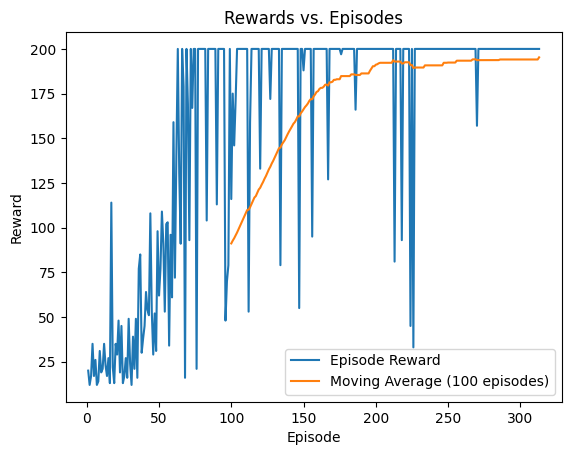

In [8]:

#print(len(episode_rewards))
episode_numbers = list(range(1, len(episode_rewards) + 1))
#print(len(episode_numbers))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")


moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")
plt.title('Rewards vs. Episodes')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


# Testing the Model

In [9]:


env = gym.make("CartPole-v0")


#  discount factor
gamma = 0.95
#  gradient clipping
max_grad_norm = 1


episode_rewards = []


for episode in range(500):
    obs_history_eps = []
    reward_history_eps = []
    action_history_eps = []
    terminated = False
    truncated = False

    while (not terminated) and (not truncated):
        # sampling an action from the policy
        obs_array = np.array(obs_history_eps[-1] if obs_history_eps else env.reset()[0], dtype=np.float32)
        obs_array = obs_array.reshape((1, 4))  # Reshape to 1D array
        obs_tensor =tf.convert_to_tensor(obs_array)


        prob = model_policy.forward(obs_tensor)
        #print("probability", prob)
        dist = tfp.distributions.Categorical(probs=prob, dtype=tf.float32)
        #print("disribution", dist)
        action = dist.sample()
        #print("selected proba", prob[0][int(action)])

        obs, reward, terminated, truncated, info=  env.step(int(action.numpy()[0]))

        obs_history_eps.append(obs)
        reward_history_eps.append(reward)
        action_history_eps.append(action)
        selected_probs_eps.append(prob[0][int(action)])

    
    episode_rewards.append(sum(reward_history_eps))
    

# Close the environment
env.close()


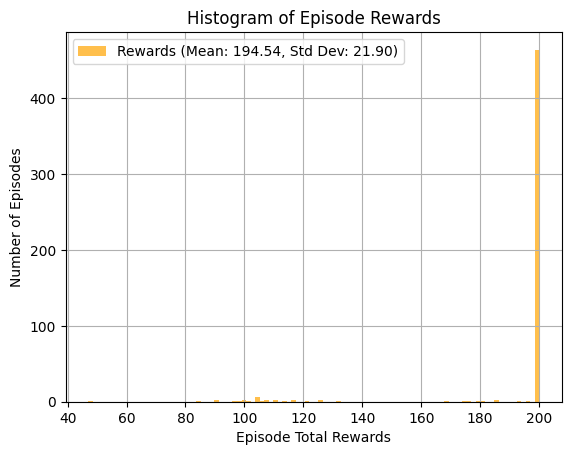

In [12]:
mean_reward = np.mean(episode_rewards)
std_reward = np.std(episode_rewards)


# Create a histogram
plt.hist(episode_rewards, bins=100, color='orange', alpha=0.7)
plt.xlabel('Episode Total Rewards')
plt.ylabel('Number of Episodes')
plt.title('Histogram of Episode Rewards')
plt.legend([f'Rewards (Mean: {mean_reward:.2f}, Std Dev: {std_reward:.2f})'])
plt.grid(True)




# Show the histogram
plt.show()
